In [2]:
import numpy as np
import scipy.linalg as LA
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''
\usepackage{physics} \usepackage{upgreek} \usepackage{mhchem} \usepackage{bm}
'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

from scipy.optimize import brentq
from scipy.optimize import curve_fit

import mpmath, scipy
import seaborn as sns


In [170]:
def rho0(Nk):
    rho = np.zeros((2,2,Nk))
    rho[0,0,:] = 1
    return rho

def h_k(k, rho, K, phys_parameters, eps0, include_hartree=True):
    b, t, t_, epsilon, Vb, Vc = phys_parameters
    Nk = rho.shape[-1]
    hk = np.zeros((2,2), dtype='complex')
    hk[0,0] += 2*t*np.cos(k) - epsilon
    hk[1,1] += -2*t_*np.cos(k) + epsilon

    if include_hartree == True:
        hk[0,0] += (Vb + Vc)*np.sum(rho[1,1,:])/Nk
        hk[1,1] += (Vb + Vc)*np.sum(rho[0,0,:])/Nk

    ad = - 1/Nk * Vb * np.sum(rho[1,0,:]) - 1/Nk * Vc * np.sum(rho[1,0,:] * np.exp(-1j*K)) * np.exp(-1j*k)
    hk[0,1] += ad
    hk[1,0] += ad.conj()

    if eps0 != 0:
        hk[0,1] += 2*eps0*1j*np.sin(k)
        hk[1,0] += - 2*eps0*1j*np.sin(k)
    return hk

def diagonalize(rho, K, T, mu, phys_parameters, eps0, include_hartree=True):
    Nk = len(K)
    energije, vecs = np.zeros((2,Nk)), np.zeros((2,2,Nk), dtype='complex')
    fs = np.zeros((2,2,Nk))
    for i in range(Nk):
        en, v = LA.eigh(h_k(K[i], rho, K, phys_parameters, eps0, include_hartree))
        energije[:,i] = en
        vecs[:,:,i] = v
        if T == 0: np.fill_diagonal(fs[:, :, i], np.array([1, 0]))
        else: np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
    return energije, vecs, fs

def F(rho, K, T, mu, phys_parameters, eps0, include_hartree=True):
    _, vecs, fs = diagonalize(rho, K, T, mu, phys_parameters, eps0, include_hartree)
    rho_new = np.einsum('ijk,jmk,mnk->ink', vecs, fs, np.swapaxes(vecs.conj(),0,1))
    return rho_new, np.max(np.abs(rho - rho_new))

def zasedenost(rho):
    return (np.sum(np.diag(np.einsum('ijk->ij', rho)))/(np.prod(rho.shape[-1]))).real

def Rho_next(rho, K, T, mu, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=0.5, include_hartree=True):
    err, N_iters = 1, 0
    while err > epsilon_threshold and N_iters < maxiter:
        if N_iters < N_epsilon: eps = eps0
        else: eps = 0
        rho_new, err = F(rho, K, T, mu, phys_parameters, eps, include_hartree)
        rho = rho_new * mix + rho * (1 - mix)
        N_iters += 1
    rho, _ = F(rho, K, T, mu, phys_parameters, 0, include_hartree)
    energije, vecs, fs = diagonalize(rho, K, T, mu, phys_parameters, 0, include_hartree)
    return rho, err, energije, vecs, fs, zasedenost(rho)

def Phi(K, rho):
    Nk = rho.shape[-1]
    return [1/Nk * np.sum(rho[0,1,:] * np.exp(-1j*K*delta)).real for delta in [0,1]]

def NewMu(K, rho, T, mu, dmu, phys_parameters, eps0, epsilon_threshold, N_epsilon, maxiter, n_pass=1e-4, mix2=0.001, mix3=1.5, max_trials=30, mix=0.5,
          include_hartree=True):
    rho_a, err_a, energije_a, vecs_a, fs_a, n_a = Rho_next(rho, K, T, mu, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=mix, include_hartree=include_hartree)
    if np.abs(n_a - 1) < n_pass and err_a < epsilon_threshold:
        return rho_a, err_a, energije_a, vecs_a, fs_a, n_a, mu
    n_b = Rho_next(rho, K, T, mu + dmu, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=0.5, include_hartree=include_hartree)[-1]
    chi = (n_b - n_a)/dmu
    if chi != 0: mu = mu - mix2 * (n_a - 1)/np.abs(chi)

    pogoj = False
    koraki = 0
    if np.abs(chi) > 0: faktor = (n_a - 1)/chi * mix3
    else: faktor = 0.1
    if chi >= 0:
        if n_a >= 1:
            sign = -1
        elif n_a < 1: sign = +1
    elif chi < 0:
        if n_a > 1: sign = +1
        elif n_a < 1: sign = -1
        
    sgns = np.ones(2) * np.sign(n_a - 1)
    ns = np.array([0, n_a])
    mus = [0, mu]
    enough = False
    while sgns[0] == sgns[1]:
        if np.abs(n_a - 1) < n_pass and err_a < epsilon_threshold:
            enough = True
            break
        rho_b, err_b, energije_b, vecs_b, fs_b, n_b = Rho_next(rho, K, T, mu + faktor*koraki*sign, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=mix, include_hartree=include_hartree)
        if np.abs(n_b - 1) < n_pass and err_b < epsilon_threshold:
            return rho_b, err_b, energije_b, vecs_b, fs_b, n_b, mu + faktor*koraki*sign
        ns[0] = n_b
        mus[0] = mu + faktor*koraki*sign
        sgns[1] = np.sign(n_b - 1)
        if sgns[0] != sgns[1]: break
        if n_b < 1 and n_b < ns[1]: sign *= -1
        if n_b > 1 and n_b > ns[1]: sign *= -1
        ns = np.roll(ns, 1)
        mus = np.roll(mus, 1)
        sgns[1] = np.sign(n_b - 1)
        koraki += 1
        if np.abs(n_b - 1) < n_pass and err_b < epsilon_threshold:
            enough = True
            mu_mid = mu + faktor*koraki*sign
            break
        
    mus = np.sort(np.array([mu + faktor*koraki*sign, mu + faktor*(koraki-1)*sign]))
    ns = np.sort(np.array(ns))

    trials = 0
    while pogoj == False:
        if enough == True:
            break   
        mu_mid = (mus[0] + mus[1])/2
        n_mid = Rho_next(rho, K, T, mu_mid, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=mix, include_hartree=include_hartree)[-1]
        if n_mid > 1: mus[1] = mu_mid
        elif n_mid < 1: mus[0] = mu_mid
        if np.abs(n_mid - 1) < n_pass: break
        trials += 1 
        if trials > max_trials: break
    rho, err, energije, vecs, fs, n = Rho_next(rho, K, T, mu_mid, phys_parameters, eps0,
             epsilon_threshold, N_epsilon, maxiter, mix=mix, include_hartree=include_hartree)
    return rho, err, energije, vecs, fs, n, mu_mid

''' df/domega, f je Fermi-Diracova porazdelitvena funkcija '''
def fd_1(omega, T): return -1/(4*T)/np.cosh(omega/(2*T))**2

def parameters(phys_parameters, mu=0):
    b, t, t_, epsilon, Vb, Vc = phys_parameters
    kinetic = [(1, 1, 1, t),
               (-1, 1, 1, t),
               (1, 2, 2, -t_),
               (-1, 2, 2, -t_ ),
               (0, 1, 1, -epsilon - mu),
               (0, 2, 2, epsilon - mu)]
    interaction = [(0, 1, 2, Vb/2),
                   (0, 2, 1, Vb/2),
                   (1, 1, 2, Vc/2),
                   (-1, 2, 1, Vc/2)]
    pos = {1: 0., 2: b}
    return pos, kinetic, interaction

''' matrix for number density operator '''
def j_tok(K, phys_parameters, mu):
    Nk = len(K)
    pos, kinetic, interaction = parameters(phys_parameters, mu)

    Nk = len(K)
    j = np.zeros((2, 2, Nk), dtype='complex')
    for line in kinetic:
        (x, orb1, orb2, t) = list(map(float,line))
        orb1, orb2 = int(orb1), int(orb2)
        ad = 1j * t * np.exp(-1j * K * x) * (pos[orb2] - pos[orb1] - x)
        j[orb1 - 1, orb2 - 1] += ad
        if orb1 != orb2:
            j[orb2 - 1, orb1 - 1] += ad.conjugate()

    j_K = np.zeros((2, 2, Nk), dtype='complex')
    for line in kinetic:
        (x, orb1, orb2, t) = list(map(float,line))
        orb1, orb2 = int(orb1), int(orb2)
        for line_ in kinetic:
            (x_, orb1_, orb2_, t_) = list(map(float,line_))
            orb1_, orb2_ = int(orb1_), int(orb2_)
            if orb2 == orb1_:
                ad = - 1j * 0.5 * t * t_ * np.exp(-1j * K * (x + x_)) * (pos[orb1] - pos[orb2_] + (x+x_)) / Nk
                j_K[orb1 - 1, orb2_ - 1] += ad

    j_I = np.zeros((2, 2, 2, Nk, Nk), dtype='complex')
    for line in kinetic:
        (x, orb1, orb2, t) = list(map(float,line))
        if orb1 == orb2 and x == 0: pass
        else:
            orb1, orb2 = int(orb1), int(orb2)
            for line_ in interaction:
                (x_, orb1_, orb2_, V_) = list(map(float,line_))
                orb1_, orb2_ = int(orb1_), int(orb2_)

                if orb2 == orb2_:
                    for ind_q, q in enumerate(K):
                        ad = -1j * t * V_ * np.exp(-1j * (K*x + q*x_)) * np.exp(-1j*q*x) * (pos[orb1] - pos[orb1_] + (x-x_))
                        j_I[orb1 - 1, orb1_ - 1, orb2 - 1, :, ind_q] += ad

                if orb1 == orb2_:
                    for ind_q, q in enumerate(K):
                        ad = 1j * t * V_ * np.exp(-1j * (K*x + q*x_)) * (pos[orb2] - pos[orb1_] - (x+x_)) / Nk
                        j_I[orb1 - 1, orb1_ -1, orb2 -1, :, ind_q] += ad
    return j, j_K, j_I 

''' create TNS class '''
class model:
    def __init__(self, Nk, mu0, phys_parameters, parameters1, parameters2, mix=0.5, include_hartree=True):
        self.b, self.t, self.t_, self.epsilon, self.Vb, self.Vc = phys_parameters
        self.K = 2*np.pi * np.arange(-Nk/2, Nk/2) / Nk
        self.Nk = Nk
        self.parameters1 = parameters1
        self.parameters2 = parameters2
        self.phys_parameters = phys_parameters
        self.mix = mix
        self.include_hartree = include_hartree
        self.mu = mu0

        self.phis = []
        self.mus = []
        self.errors = []
        self.occupations = []
        self.times_rho = []
        self.times_boltzmann = []
        self.times_kubo = []
        self.Ts = []
        self.betas = []

        self.energije0 = np.vstack([2*self.t*np.cos(self.K) - self.epsilon, -2*self.t_*np.cos(self.K) + self.epsilon])
        if include_hartree == True:
                self.energije0[1,:] += self.Vb + self.Vc

    def GS(self):
        rho, err, energije, vecs, fs, n = Rho_next(rho0(self.Nk), self.K, 0, self.mu, self.phys_parameters, self.parameters1['eps0'],
                                                  self.parameters1['epsilon_threshold'], self.parameters1['N_epsilon'], self.parameters1['maxiter'], mix=self.mix, 
                                                  include_hartree=self.include_hartree)
        self.rho = rho
        self.energije = energije
        self.vecs = vecs
        self.fs = fs
        self.phi = Phi(self.K, self.rho)
        self.j_matrix = j_tok(self.K, self.phys_parameters, self.mu)

        print(f'found ground state, err={err}, n_err={np.abs(n-1)}, phi={self.phi}')

    def next_T(self, T, i) -> None:
        if i == 1: parameters = self.parameters1
        elif i == 2: parameters = self.parameters2
        eps0 = parameters['eps0']
        dmu = parameters['dmu']
        epsilon_threshold = parameters['epsilon_threshold']
        N_epsilon = parameters['N_epsilon']
        maxiter = parameters['maxiter']
        n_pass = parameters['n_pass']
        rho, err, energije, vecs, fs, n, mu = NewMu(self.K, self.rho, T, self.mu, dmu,
                                                        self.phys_parameters, eps0, epsilon_threshold, N_epsilon, maxiter, n_pass, include_hartree=self.include_hartree)
        self.rho = rho
        self.energije = energije
        self.fs = fs
        self.vecs = vecs
        self.err = err
        self.n = n
        self.mu = mu
        self.phi = Phi(self.K, self.rho)
        print(1/T, err, n, self.phi)

    def run(self, Ts, Gamma=0.01):
        for _, T in enumerate(Ts):
            if T == Ts[-1]:
                self.next_T(T, 1)
                self.Ts.append(T)
                self.betas.append(1/T)
                self.phis.append(self.phi)
                self.mus.append(self.mu)
                self.errors.append(self.err)
                self.occupations.append(self.n)
                self.j_matrix = j_tok(self.K, self.phys_parameters, self.mu)

                fs = np.zeros((2,2,self.Nk))
                for i in range(self.Nk):
                    np.fill_diagonal(fs[:, :, i], 1/(1 + np.exp((self.energije[:,i] - self.mu)/T)))
            else:
                self.next_T(T, 2)

    def reset(self, mu0):
        self.GS()
        self.mu = mu0
        
    def reset_highT(self):
        rho1, err1, energije1, vecs1, fs1, n1 = Rho_next(rho0(self.Nk), self.K, 0, self.mu, self.phys_parameters, 0,
             self.parameters1['epsilon_threshold'], self.parameters1['N_epsilon'], self.parameters1['maxiter'], mix=self.mix, 
                                                  include_hartree=self.include_hartree)
        self.rho = rho1
        self.energije = energije1
        self.vecs = vecs1
        self.fs = fs1
        self.n = n1




In [171]:
set_betas = 200/1.001**np.arange(10)
set_Ts = 1/set_betas
Gamma = 0.01

parameters1 = {'n_pass': 1e-3,
               'epsilon_threshold' : 1e-4,
               'N_epsilon' : 5,
                'maxiter' : 50,
                'eps_last': 1e-4,
                'dmu': 0.1,
                'mix2': 0.001,
                'mix3': 1.5,
                'faktor1': 0.1,
                'max_trials':5,
                'eps0': 0.03
               }

parameters2 = {'n_pass': 1e-3,
               'epsilon_threshold' : 1e-4,
               'N_epsilon' : 5,
                'maxiter' : 20,
                'eps_last': 1e-4,
                'dmu': 0.1,
                'mix2': 0.001,
                'mix3': 1.5,
                'faktor1': 0.1,
                'max_trials':5,
                'eps0': 0.03
               }

epsilon_threshold = 1e-10
N_epsilon = 5
maxiter = 100

a = 1
b = a/2

t = 1
t_ = 1.*t
epsilon = 1.95*t
Vb = 0.5*t#1.2*t
Vc = 0.5*t#0.4*t#.2*t


Nk = 250
phys_parameters = [b, t, t_, epsilon, Vb, Vc]
mu0 = 0
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree=False)
m.GS()

found ground state, err=7.22575169357087e-05, n_err=0.0, phi=[np.float64(0.08169117622997331), np.float64(0.0626218927848949)]


In [172]:

mu0=0.
scale = 1.05
beta0 = 403
betas = [35]#np.linspace(2,20,30)[::-1]#21,19,17,15,14,13,12.5,12,11.5,11,10.75,10.5,10.25,10,9.75,9.5,9.25,9,8.5,8,7,6,5,4,3])
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/np.array(betas)
for i, T in enumerate(Ts):
    m.reset(mu0)
    set_betas = beta0/scale**np.arange(ends[i])
    set_Ts = 1/set_betas
    m.run(set_Ts, 0.05)

found ground state, err=7.22575169357087e-05, n_err=0.0, phi=[np.float64(0.08169117622997331), np.float64(0.0626218927848949)]


KeyboardInterrupt: 

(-0.5, 0.5)

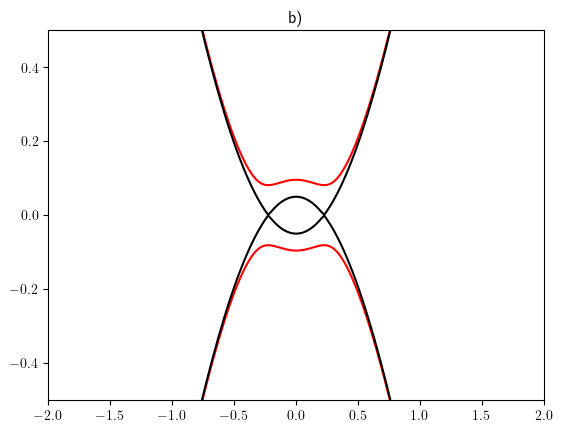

In [159]:
plt.title('b)')
plt.plot(m.K, m.energije[0] - m.mu, color='red')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='black')
plt.plot(m.K, m0.energije[1] - m0.mu, color='black')

plt.xlim(-2,2)
plt.ylim(-0.5,0.5)

0

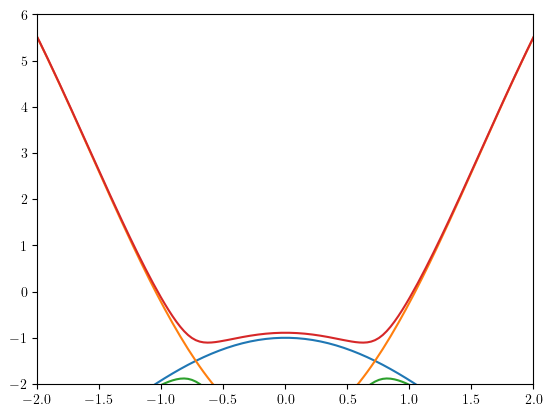

In [97]:
plt.plot(m.K, m.energije0[0] - m.mu)
plt.plot(m.K, m.energije0[1])

plt.plot(m.K, m.energije[0])
plt.plot(m.K, m.energije[1])
plt.ylim(-2,6)
plt.xlim(-2,2)
m.mu